In [6]:
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

############### 数据获取 ################
def generate_raw_atcg_sequences(num_samples, seq_length, batch_size):
    print(f"\n生成 {num_samples} 个 {seq_length}bp 序列")
    
    # 1. 定义单碱基词表，字符转数字
    char_vocab = {'<PAD>': 0, 'A': 1, 'T': 2, 'C': 3, 'G': 4, 'N': 5}
    
    # 2. 生成模拟 DNA 序列 (正样本植入 TATA box)
    bases = ['A', 'T', 'C', 'G']
    raw_seqs, raw_labels = [], []
    ### 生成负样本
    for _ in range(int(num_samples/2)):
        raw_seqs.append(''.join(np.random.choice(bases, seq_length)))
        raw_labels.append(0)
    ### 生成正样本
    for _ in range(int(num_samples/2)):
        seq_list = list(np.random.choice(bases, seq_length))
    # 植入 TATA box
        insert_pos = random.randint(60, 70) 
        seq_list[insert_pos : insert_pos + 7] = list("TATAAAA")
        raw_seqs.append(''.join(seq_list))
        raw_labels.append(1)
        
    # 3. 单碱基数字化与 Padding
    X_indices = []
    for seq in raw_seqs:
        padded = [char_vocab.get(b, 5) for b in seq][:seq_length]
        if len(padded) < seq_length:
            padded += [0] * (seq_length - len(padded))
        X_indices.append(padded)
        
    X = np.array(X_indices)
    y = np.array(raw_labels)
    
    # 4. 分区划分训练集、测试集和验证集，以及 DataLoader 封装
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    def to_loader(X_data, y_data, shuffle):
        tensor_x = torch.tensor(X_data, dtype=torch.long)
        tensor_y = torch.tensor(y_data, dtype=torch.long)
        final_xy = DataLoader(TensorDataset(tensor_x, tensor_y), batch_size=batch_size, shuffle=shuffle)
        return final_xy
    
    train_loader = to_loader(X_train, y_train, shuffle=True)
    valid_loader = to_loader(X_valid, y_valid, shuffle=False)
    test_loader = to_loader(X_test, y_test, shuffle=False)
    
    print(f"数据处理完成！获得训练集: {len(y_train)} | 验证集: {len(y_valid)} | 测试集: {len(y_test)}")
    return train_loader, valid_loader, test_loader, char_vocab

# 运行,获取数据
train_loader, valid_loader, test_loader, vocab = generate_raw_atcg_sequences(num_samples=5000, seq_length=100,batch_size=32)


生成 5000 个 100bp 序列
数据处理完成！获得训练集: 3500 | 验证集: 750 | 测试集: 750


In [ ]:
import torch.nn as nn
import torch.optim as optim
import math
import copy

############### 模型构建 ################
## 模型超参数
VOCAB_SIZE = 6
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
NUM_CLASSES = 2
MAX_SEQ_LEN = 100

class CNN_DNA_Transformer(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD, 
                 num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, max_seq_len=MAX_SEQ_LEN):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        # CNN 提取局部 Motif，取代 k-mer
        self.conv1d = nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=7, padding=3)
        self.relu = nn.ReLU()
        self.cnn_dropout = nn.Dropout(0.1)
        # 可学习位置编码，取代 sin/cos
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=256, dropout=0.2, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.classifier_dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim) 
        
        # CNN 局部特征提取
        x = x.permute(0, 2, 1) 
        x = self.cnn_dropout(self.relu(self.conv1d(x)))
        x = x.permute(0, 2, 1) 
        
        # 注入位置信息
        positions = torch.arange(0, seq_len, dtype=torch.long, device=x.device).unsqueeze(0)
        x = x + self.pos_embedding(positions)
        
        x = self.transformer_encoder(x)
        x = x.mean(dim=1) # 全局池化
        return self.fc(self.classifier_dropout(x))

# def train_model(train_loader, valid_loader, num_epochs=10):
print("\n正在初始化 CNN-Transformer 架构...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 笔记本为CPU
model = CNN_DNA_Transformer().to(device)
    
criterion = nn.CrossEntropyLoss() #损失函数
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) # 优化器，添加L2正则化
    
best_val_acc = 0.0
best_model_weights = None
num_epochs = 10
print(f"开始训练模型...")
for epoch in range(num_epochs):
    model.train()
    train_correct, train_total = 0, 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
            
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
            
    # 模型验证评估
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
                
    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1:02d}/{num_epochs}] Train Acc: {100 * train_correct / train_total:.2f}% | Val Acc: {val_acc:.2f}%")
        
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
            
# 将最优权重加载回模型并返回
model.load_state_dict(best_model_weights)
torch.save(best_model_weights, 'best_cnn_transformer.pth')
print(f"训练完成！最佳验证集准确率为: {best_val_acc:.2f}%")



正在初始化 CNN-Transformer 架构...
开始训练模型...
Epoch [01/10] Train Acc: 81.83% | Val Acc: 98.93%
Epoch [02/10] Train Acc: 99.11% | Val Acc: 99.60%
Epoch [03/10] Train Acc: 99.66% | Val Acc: 99.73%
Epoch [04/10] Train Acc: 99.40% | Val Acc: 99.47%
Epoch [05/10] Train Acc: 99.63% | Val Acc: 99.60%
Epoch [06/10] Train Acc: 99.66% | Val Acc: 99.87%
Epoch [07/10] Train Acc: 99.80% | Val Acc: 99.87%
Epoch [08/10] Train Acc: 99.43% | Val Acc: 97.47%
Epoch [09/10] Train Acc: 99.49% | Val Acc: 99.87%
Epoch [10/10] Train Acc: 99.34% | Val Acc: 99.87%
训练完成！最佳验证集准确率为: 99.87%


最终测试集准确率为: 100.00%

                         precision    recall  f1-score   support

Negative (Non-Promoter)       1.00      1.00      1.00       375
    Positive (Promoter)       1.00      1.00      1.00       375

               accuracy                           1.00       750
              macro avg       1.00      1.00      1.00       750
           weighted avg       1.00      1.00      1.00       750



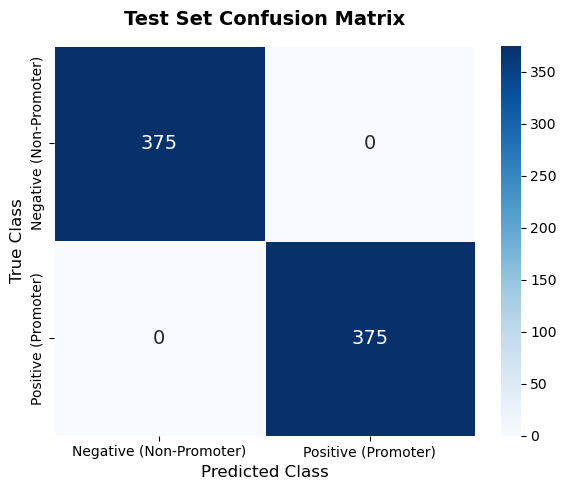

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
model.load_state_dict(torch.load('best_cnn_transformer.pth', map_location=device, weights_only=True))
model.eval()
all_preds, all_labels = [], []

# 关闭梯度计算以节省显存/内存并加速推理
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # 模型前向传播
        outputs = model(batch_x)
        
        # 获取预测概率最大的类别索引
        _, predicted = torch.max(outputs, 1)
        
        # 收集预测结果和真实标签
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
        
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 计算最终准确率
test_acc = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"最终测试集准确率为: {test_acc:.2f}%\n")
    
# 输出分类报告
target_names = ["Negative (Non-Promoter)", "Positive (Promoter)"]
print(classification_report(all_labels, all_preds, target_names=target_names))
    
# 绘制混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            linewidths=.5, annot_kws={"size": 14})
    
plt.title('Test Set Confusion Matrix', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()
